In [1]:
import numpy as np
import pandas as pd


In [2]:
df= pd.read_csv("C:/Users/Dell/Downloads/customer_churn_dataset.csv")
df

,customer_id,tenure,monthly_charges,total_charges,contract,payment_method,internet_service,tech_support,online_security,support_calls,churn
0,1,52,54.20,2818.40,Month-to-month,Credit,DSL,No,Yes,1,No
1,2,15,35.28,529.20,Month-to-month,Debit,DSL,No,No,2,No
2,3,72,78.24,5633.28,Month-to-month,Debit,DSL,No,No,0,No
3,4,61,80.24,4894.64,One year,Cash,Fiber,Yes,Yes,0,No
4,5,21,39.38,826.98,Month-to-month,UPI,Fiber,No,No,4,Yes
...,...,...,...,...,...,...,...,...,...,...,...
19995,19996,36,69.51,2502.36,Two year,Cash,DSL,No,Yes,0,Yes
19996,19997,10,59.88,598.80,Month-to-month,UPI,Fiber,Yes,No,1,No
19997,19998,6,42.96,257.76,Month-to-month,Credit,Fiber,No,No,2,No
19998,19999,7,102.85,719.95,Month-to-month,Debit,DSL,Yes,No,2,No


In [3]:
df.head()

,customer_id,tenure,monthly_charges,total_charges,contract,payment_method,internet_service,tech_support,online_security,support_calls,churn
0,1,52,54.20,2818.40,Month-to-month,Credit,DSL,No,Yes,1,No
1,2,15,35.28,529.20,Month-to-month,Debit,DSL,No,No,2,No
2,3,72,78.24,5633.28,Month-to-month,Debit,DSL,No,No,0,No
3,4,61,80.24,4894.64,One year,Cash,Fiber,Yes,Yes,0,No
4,5,21,39.38,826.98,Month-to-month,UPI,Fiber,No,No,4,Yes


In [4]:
df.tail()

,customer_id,tenure,monthly_charges,total_charges,contract,payment_method,internet_service,tech_support,online_security,support_calls,churn
19995,19996,36,69.51,2502.36,Two year,Cash,DSL,No,Yes,0,Yes
19996,19997,10,59.88,598.80,Month-to-month,UPI,Fiber,Yes,No,1,No
19997,19998,6,42.96,257.76,Month-to-month,Credit,Fiber,No,No,2,No
19998,19999,7,102.85,719.95,Month-to-month,Debit,DSL,Yes,No,2,No
19999,20000,31,44.84,1390.04,Two year,Credit,Fiber,Yes,No,1,Yes


In [5]:
df.describe()

,customer_id,tenure,monthly_charges,total_charges,support_calls
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000
mean,10000.500000,36.467450,70.010531,2543.979209,1.51255
std,5773.647028,20.773984,28.890239,1882.949804,1.23524
min,1.000000,1.000000,20.000000,20.230000,0.00000
25%,5000.750000,18.000000,45.210000,1045.837500,1.00000
50%,10000.500000,36.000000,70.090000,2096.495000,1.00000
75%,15000.250000,54.000000,95.072500,3690.337500,2.00000
max,20000.000000,72.000000,120.000000,8629.920000,8.00000


In [6]:
df.isnull().sum()

customer_id            0
tenure                 0
monthly_charges        0
total_charges          0
contract               0
payment_method         0
internet_service    2013
tech_support           0
online_security        0
support_calls          0
churn                  0
dtype: int64

In [7]:
df.dtypes

customer_id           int64
tenure                int64
monthly_charges     float64
total_charges       float64
contract                str
payment_method          str
internet_service        str
tech_support            str
online_security         str
support_calls         int64
churn                   str
dtype: object

In [8]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
# Check unique values in categorical columns

categorical_columns = [
    'contract',
    'payment_method',
    'internet_service',
    'tech_support',
    'online_security',
    'churn'
]

for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].value_counts(dropna=False))


contract:
contract
Month-to-month    11942
One year           4990
Two year           3068
Name: count, dtype: int64

payment_method:
payment_method
Credit    5026
Debit     5025
Cash      4995
UPI       4954
Name: count, dtype: int64

internet_service:
internet_service
Fiber    10064
DSL       7923
NaN       2013
Name: count, dtype: int64

tech_support:
tech_support
No     13031
Yes     6969
Name: count, dtype: int64

online_security:
online_security
No     12008
Yes     7992
Name: count, dtype: int64

churn:
churn
No     13157
Yes     6843
Name: count, dtype: int64


In [11]:
for column in ['internet_service', 'tech_support', 'online_security', 'churn']:
    print(f"\n{column}:")
    print(df[column].value_counts(dropna=False))


internet_service:
internet_service
Fiber    10064
DSL       7923
NaN       2013
Name: count, dtype: int64

tech_support:
tech_support
No     13031
Yes     6969
Name: count, dtype: int64

online_security:
online_security
No     12008
Yes     7992
Name: count, dtype: int64

churn:
churn
No     13157
Yes     6843
Name: count, dtype: int64


In [12]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate customer IDs:", df['customer_id'].duplicated().sum())

Duplicate rows: 0
Duplicate customer IDs: 0


In [13]:
# Look at customers with missing internet_service
missing_internet = df[df['internet_service'].isna()]

print("Customers with missing internet_service:", len(missing_internet))

missing_internet.head()

Customers with missing internet_service: 2013


,customer_id,tenure,monthly_charges,total_charges,contract,payment_method,internet_service,tech_support,online_security,support_calls,churn
11,12,38,49.50,1881.00,Month-to-month,Debit,NaN,No,Yes,1,Yes
32,33,51,90.90,4635.90,Month-to-month,Credit,NaN,No,No,6,Yes
45,46,44,74.24,3266.56,Two year,Cash,NaN,No,No,1,No
57,58,63,103.03,6490.89,Month-to-month,UPI,NaN,No,No,1,Yes
67,68,40,63.91,2556.40,Month-to-month,UPI,NaN,Yes,No,0,Yes


In [14]:
# Compare missing internet-service customers with other service columns
missing_internet[['tech_support', 'online_security', 'contract',
                  'monthly_charges', 'total_charges', 'churn']].head(20)

,tech_support,online_security,contract,monthly_charges,total_charges,churn
11,No,Yes,Month-to-month,49.50,1881.00,Yes
32,No,No,Month-to-month,90.90,4635.90,Yes
45,No,No,Two year,74.24,3266.56,No
57,No,No,Month-to-month,103.03,6490.89,Yes
67,Yes,No,Month-to-month,63.91,2556.40,Yes
81,Yes,No,Month-to-month,92.51,5828.13,No
83,Yes,Yes,Month-to-month,37.38,299.04,Yes
85,No,No,One year,68.74,2405.90,No
89,No,No,Month-to-month,32.76,917.28,No
110,No,No,Month-to-month,53.12,2231.04,No


In [15]:
print("Average monthly charges:")
print(missing_internet['monthly_charges'].mean())

print("\nAverage total charges:")
print(missing_internet['total_charges'].mean())

print("\nChurn distribution:")
print(missing_internet['churn'].value_counts(normalize=True) * 100)

Average monthly charges:
69.3043219076006

Average total charges:
2486.463229011426

Churn distribution:
churn
No     64.778937
Yes    35.221063
Name: proportion, dtype: float64


In [16]:
#Handle Missing Values

# Check missing values before cleaning
print("Missing internet_service before:", df['internet_service'].isna().sum())

# Replace missing categorical values with 'Unknown'
df['internet_service'] = df['internet_service'].fillna('Unknown')

# Check again
print("Missing internet_service after:", df['internet_service'].isna().sum())

Missing internet_service before: 2013
Missing internet_service after: 0


In [17]:
df['internet_service'].value_counts()

internet_service
Fiber      10064
DSL         7923
Unknown     2013
Name: count, dtype: int64

In [18]:
df.isnull().sum()

customer_id         0
tenure              0
monthly_charges     0
total_charges       0
contract            0
payment_method      0
internet_service    0
tech_support        0
online_security     0
support_calls       0
churn               0
dtype: int64

In [19]:
#Churn Distribution
# Count customers in each churn category

print(df['churn'].value_counts())

churn
No     13157
Yes     6843
Name: count, dtype: int64


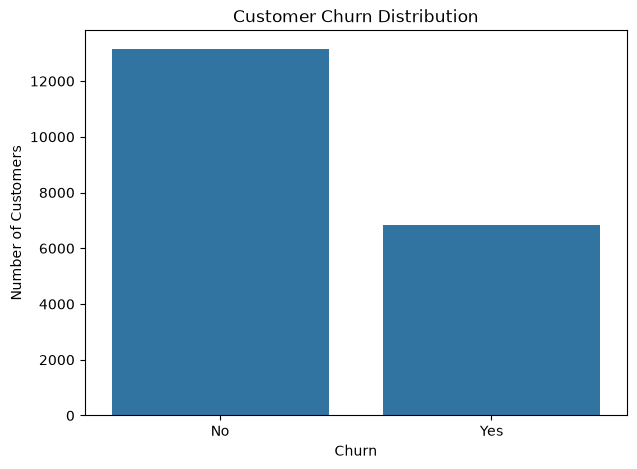

In [20]:
#churn chart

plt.figure(figsize=(7,5))

sns.countplot(data=df, x ='churn')
plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')

plt.show()

In [21]:
#6.3 — Calculate churn rate

churn_percentage = df['churn'].value_counts(normalize=True)*100

print(churn_percentage)
print(f"\n Overall Churn Rate: {churn_percentage['Yes']:.2f}%")

churn
No     65.785
Yes    34.215
Name: proportion, dtype: float64

 Overall Churn Rate: 34.22%


65.8% customers who stayed
34.2% customers who churned

This means churn is significant enough to be a business problem.

Also, because the classes aren't perfectly balanced, later we'll evaluate our models using precision, recall, F1-score and ROC-AUC, not accuracy alone.

In [22]:
#Step 7 — Contract Type vs Churn

#Churn count by contract

contact_churn = pd.crosstab(
    df['contract'],
    df['churn']
)

print(contact_churn)

churn             No   Yes
contract                  
Month-to-month  6785  5157
One year        3946  1044
Two year        2426   642


In [23]:
## Churn percentage within each contract type

contract_churn_rate = pd.crosstab(
    df['contract'],
    df['churn'],
    normalize='index'
)*100

print(contract_churn_rate.round(2))

churn              No    Yes
contract                    
Month-to-month  56.82  43.18
One year        79.08  20.92
Two year        79.07  20.93


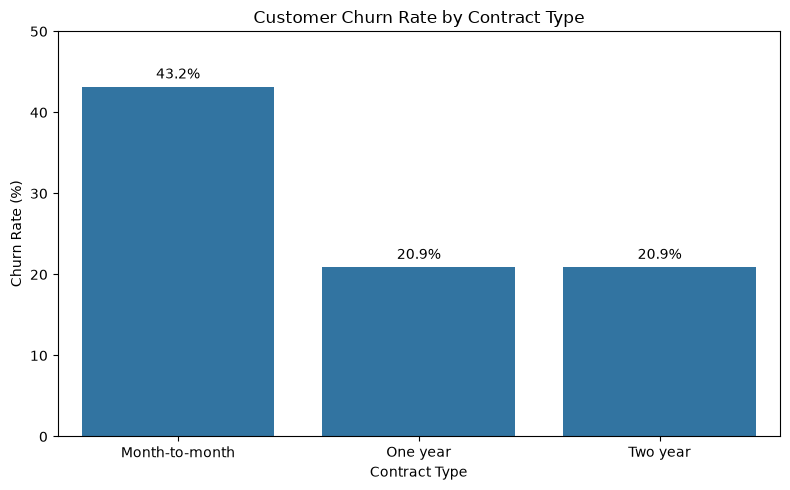

In [24]:
#7.3 — Visualize it

# Create a cleaner churn-rate chart

churn_rates = contract_churn_rate['Yes']

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=churn_rates.index,
    y=churn_rates.values
)

plt.title('Customer Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')

# Add percentage labels
for i, value in enumerate(churn_rates.values):
    ax.text(i, value + 1, f'{value:.1f}%', ha='center')

plt.ylim(0, 50)
plt.tight_layout()
plt.show()

Step 8 — Tenure vs Churn

In [25]:
#Compare average tenure

# Average tenure for customers who stayed vs churned

tenure_by_churn = df.groupby('churn')['tenure'].mean()

print(f"Average tenure - Stayed: {tenure_by_churn['No']:.2f} months")
print(f"Average tenure - Churned: {tenure_by_churn['Yes']:.2f} months")

Average tenure - Stayed: 37.78 months
Average tenure - Churned: 33.94 months


In [26]:
#Visualize tenure distribution
import plotly.express as px

fig = px.box(
    df,
    x='churn',
    y='tenure',
    color='churn',
    points=False,
    title='Tenure Distribution by Churn',
    labels={
        'churn': 'Churn',
        'tenure': 'Tenure (Months)'
    },
    hover_data={
        'churn': True,
        'tenure': True
    }
)

fig.update_layout(
    width=850,
    height=550,
    xaxis_title='Churn',
    yaxis_title='Tenure (Months)',
    showlegend=False
)

fig.show()

In [27]:
#Create tenure groups

# Create tenure groups

df['tenure_group'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=['0-12 Months', '13-24 Months', '25-48 Months', '49-72 Months']
)

print(df['tenure_group'].value_counts().sort_index())

tenure_group
0-12 Months     3266
13-24 Months    3473
25-48 Months    6562
49-72 Months    6699
Name: count, dtype: int64


In [28]:
# Churn rate by tenure group

tenure_churn_rate = pd.crosstab(
    df['tenure_group'],
    df['churn'],
    normalize='index'
) * 100

print(tenure_churn_rate.round(2))

churn            No    Yes
tenure_group              
0-12 Months   53.70  46.30
13-24 Months  67.58  32.42
25-48 Months  67.81  32.19
49-72 Months  68.76  31.24


In [29]:

import plotly.express as px

# Get churn rate for each tenure group
churn_values = tenure_churn_rate[['Yes']].reset_index()

# Create percentage column for labels
churn_values['Churn_Rate'] = churn_values['Yes'].round(2)
churn_values['Churn_Label'] = churn_values['Yes'].apply(lambda x: f'{x:.2f}%')

# Interactive bar chart
fig = px.bar(
    churn_values,
    x='tenure_group',
    y='Churn_Rate',
    color='tenure_group',
    text='Churn_Label',
    title='Customer Churn Rate by Tenure Group',
    labels={
        'tenure_group': 'Tenure Group',
        'Churn_Rate': 'Churn Rate (%)'
    },
    color_discrete_sequence=[
        '#636EFA',
        '#EF553B',
        '#00CC96',
        '#AB63FA'
    ]
)

# Format data labels and hover
fig.update_traces(
    textposition='outside',
    hovertemplate=(
        '<b>Tenure Group:</b> %{x}<br>'
        '<b>Churn Rate:</b> %{y:.2f}%'
        '<extra></extra>'
    )
)

fig.update_layout(
    width=900,
    height=550,
    template='plotly_white',
    showlegend=False,
    yaxis=dict(
        title='Churn Rate (%)',
        range=[0, max(churn_values['Churn_Rate']) + 10]
    ),
    xaxis=dict(
        title='Tenure Group'
    )
)

fig.show()

Monthly Charges vs Churn

In [30]:
#Average Monthly Charges

monthly_charges_by_churn = df.groupby('churn')['monthly_charges'].mean()

print(monthly_charges_by_churn)

print(f"\nStayed:  {monthly_charges_by_churn['No']:.2f}")
print(f"Churned: {monthly_charges_by_churn['Yes']:.2f}")

churn
No     64.911829
Yes    79.813779
Name: monthly_charges, dtype: float64

Stayed:  64.91
Churned: 79.81


In [31]:
import plotly.express as px

fig = px.box(
    df,
    x='churn',
    y='monthly_charges',
    color='churn',
    points=False,
    title='Monthly Charges Distribution by Churn',
    labels={
        'churn': 'Churn',
        'monthly_charges': 'Monthly Charges'
    },
    color_discrete_map={
        'No': '#00CC96',
        'Yes': '#EF553B'
    }
)

fig.update_layout(
    width=900,
    height=550,
    template='plotly_white',
    showlegend=False
)

fig.update_traces(
    hovertemplate=(
        '<b>Churn:</b> %{x}<br>'
        '<b>Monthly Charges:</b> %{y:.2f}'
        '<extra></extra>'
    )
)

fig.show()

In [32]:
#Create Monthly Charge Groups

# Create monthly charge groups

df['monthly_charge_group'] = pd.cut(
    df['monthly_charges'],
    bins=[0, 30, 60, 90, 120, float('inf')],
    labels=[
        '0-30',
        '31-60',
        '61-90',
        '91-120',
        '120+'
    ]
)

print(df['monthly_charge_group'].value_counts().sort_index())

monthly_charge_group
0-30      1986
31-60     6079
61-90     5892
91-120    6043
120+         0
Name: count, dtype: int64


In [33]:
# Churn rate by monthly charge group

charge_churn_rate = pd.crosstab(
    df['monthly_charge_group'],
    df['churn'],
    normalize='index'
) * 100

print(charge_churn_rate.round(2))

churn                    No    Yes
monthly_charge_group              
0-30                  75.83  24.17
31-60                 77.68  22.32
61-90                 67.28  32.72
91-120                49.07  50.93


Step 10 — Tech Support & Online Security vs Churn

In [34]:
#Tech Support vs Churn

tech_support_churn = pd.crosstab(
    df['tech_support'],
    df['churn'],
    normalize='index'
)*100

print(tech_support_churn.round(2))

churn            No    Yes
tech_support              
No            58.61  41.39
Yes           79.21  20.79


Create interactive chart

In [35]:
import plotly.express as px

tech_values = tech_support_churn['Yes'].reset_index()
tech_values['Churn_Rate'] = tech_values['Yes']
tech_values['Churn_Label'] = tech_values['Yes'].apply(lambda x: f'{x:.2f}%')

fig = px.bar(
    tech_values,
    x='tech_support',
    y='Churn_Rate',
    color='tech_support',
    text='Churn_Label',
    title='Customer Churn Rate by Tech Support',
    labels={
        'tech_support': 'Tech Support',
        'Churn_Rate': 'Churn Rate (%)'
    },
    color_discrete_sequence=['#636EFA', '#EF553B']
)

fig.update_traces(
    textposition='outside',
    hovertemplate=(
        '<b>Tech Support:</b> %{x}<br>'
        '<b>Churn Rate:</b> %{y:.2f}%'
        '<extra></extra>'
    )
)

fig.update_layout(
    width=850,
    height=500,
    template='plotly_white',
    showlegend=False,
    yaxis=dict(
        title='Churn Rate (%)',
        range=[0, max(tech_values['Churn_Rate']) + 10]
    )
)

fig.show()

In [36]:
#Online Security vs Churn


# Churn rate by online security

security_churn = pd.crosstab(
    df['online_security'],
    df['churn'],
    normalize='index'
) * 100

print(security_churn.round(2))

churn               No    Yes
online_security              
No               66.03  33.97
Yes              65.42  34.58


In [37]:
fig = px.bar(
    tech_support_churn,
    y='Yes',
    color=tech_support_churn.index,
    text='Yes'
)

fig.update_traces(texttemplate='%{text:.2f}%', textposition='outside')
fig.show()

In [38]:
#Online Security vs Churn

security_churn = pd.crosstab(
    df['online_security'],
    df['churn'],
    normalize='index'
) * 100

security_churn.round(2)

churn,No,Yes
online_security,,
No,66.03,33.97
Yes,65.42,34.58


In [39]:
fig = px.bar(
    security_churn,
    y='Yes',
    color=security_churn.index,
    text='Yes',
    title='Churn Rate by Online Security'
)

fig.update_traces(
    texttemplate='%{text:.2f}%',
    textposition='outside'
)

fig.update_yaxes(
    range=[0, security_churn['Yes'].max() + 8]
)

fig.show()

Step 11 — Payment Method vs Churn

In [40]:
#11.1 Calculate churn rate.

payment_churn = pd.crosstab(
    df['payment_method'],
    df['churn'],
    normalize='index'
) * 100

payment_churn.round(2)

churn,No,Yes
payment_method,,
Cash,65.95,34.05
Credit,65.82,34.18
Debit,65.89,34.11
UPI,65.48,34.52


In [41]:
fig = px.bar(
    payment_churn,
    y='Yes',
    color=payment_churn.index,
    text='Yes',
    title='Churn Rate by Payment Method'
)

fig.update_traces(
    texttemplate='%{text:.2f}%',
    textposition='outside'
)

fig.update_yaxes(
    range=[0, payment_churn['Yes'].max() + 8]
)

fig.show()

Step 12 — Internet Service vs Churn

In [42]:
#Calculate churn rate

internet_churn = pd.crosstab(
    df['internet_service'],
    df['churn'],
    normalize='index'
) * 100

internet_churn.round(2)

churn,No,Yes
internet_service,,
DSL,66.14,33.86
Fiber,65.71,34.29
Unknown,64.78,35.22


In [43]:
fig = px.bar(
    internet_churn,
    y='Yes',
    color=internet_churn.index,
    text='Yes',
    title='Churn Rate by Internet Service'
)

fig.update_traces(
    texttemplate='%{text:.2f}%',
    textposition='outside'
)

fig.update_yaxes(
    range=[0, internet_churn['Yes'].max() + 8]
)

fig.show()

Step 13 — Numerical Features Analysis

In [44]:
df[['tenure', 'monthly_charges', 'total_charges', 'support_calls']].describe().round(2)

,tenure,monthly_charges,total_charges,support_calls
count,20000.00,20000.00,20000.00,20000.00
mean,36.47,70.01,2543.98,1.51
std,20.77,28.89,1882.95,1.24
min,1.00,20.00,20.23,0.00
25%,18.00,45.21,1045.84,1.00
50%,36.00,70.09,2096.50,1.00
75%,54.00,95.07,3690.34,2.00
max,72.00,120.00,8629.92,8.00


In [45]:
corr =df[[
    'tenure',
    'monthly_charges',
    'total_charges',
    'support_calls'
]].corr()

corr.round(2)

,tenure,monthly_charges,total_charges,support_calls
tenure,1.00,-0.02,0.77,-0.00
monthly_charges,-0.02,1.00,0.55,-0.00
total_charges,0.77,0.55,1.00,-0.01
support_calls,-0.00,-0.00,-0.01,1.00


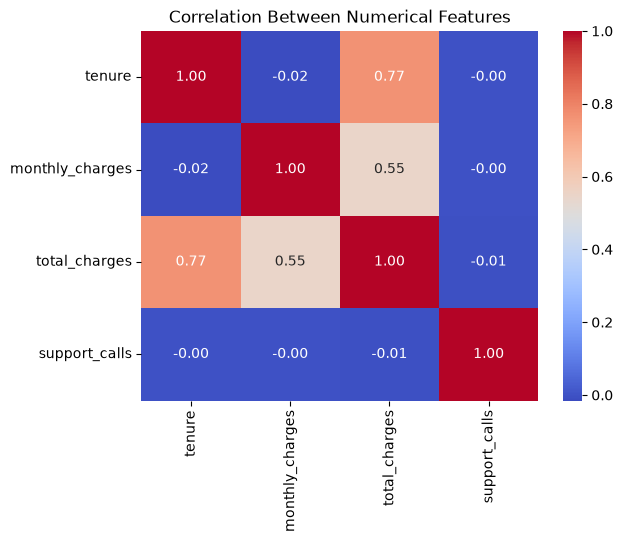

In [46]:
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Between Numerical Features')
plt.show()

Prepare Data for Machine Learning

In [47]:
df.columns.tolist()

['customer_id',
 'tenure',
 'monthly_charges',
 'total_charges',
 'contract',
 'payment_method',
 'internet_service',
 'tech_support',
 'online_security',
 'support_calls',
 'churn',
 'tenure_group',
 'monthly_charge_group']

In [48]:
df = df.drop(columns=['tenure_group', 'monthly_charge_group'])

print(df.shape)

(20000, 11)


In [49]:
df.head()

,customer_id,tenure,monthly_charges,total_charges,contract,payment_method,internet_service,tech_support,online_security,support_calls,churn
0,1,52,54.20,2818.40,Month-to-month,Credit,DSL,No,Yes,1,No
1,2,15,35.28,529.20,Month-to-month,Debit,DSL,No,No,2,No
2,3,72,78.24,5633.28,Month-to-month,Debit,DSL,No,No,0,No
3,4,61,80.24,4894.64,One year,Cash,Fiber,Yes,Yes,0,No
4,5,21,39.38,826.98,Month-to-month,UPI,Fiber,No,No,4,Yes


In [50]:
#Separate Features and Target

X = df.drop(columns=['customer_id', 'churn'])
y = df['churn']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (20000, 9)
y shape: (20000,)


In [51]:
X.dtypes

tenure                int64
monthly_charges     float64
total_charges       float64
contract                str
payment_method          str
internet_service        str
tech_support            str
online_security         str
support_calls         int64
dtype: object

Step 16 — Convert Churn to 0/1

In [52]:
y = y.map({'No': 0, 'Yes': 1})

print(y.value_counts())

churn
0    13157
1     6843
Name: count, dtype: int64


In [53]:
print(y.dtype)

int64


Train/Test Split

In [54]:
from sklearn.model_selection import train_test_split

X_train,X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Traning data:", X_train.shape)
print("Testing data:", X_test.shape )

Traning data: (16000, 9)
Testing data: (4000, 9)


In [55]:
print("Training churn rate:", y_train.mean())
print("Testing churn rate:", y_test.mean())

Training churn rate: 0.342125
Testing churn rate: 0.34225


In [57]:
#Step 18 — Build the Preprocessing Pipeline

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder


In [58]:
numeric_features = [
    'tenure',
    'monthly_charges',
    'total_charges',
    'support_calls'
]

categorical_features = [
    'contract',
    'payment_method',
    'internet_service',
    'tech_support',
    'online_security'
]

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

In [ ]:
#Step 19 — Train Our First ML Model


#model pipeline

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['tenure','monthly_charges','total_charges',...,'tech_support', 'online_security','support_calls']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remain

In [60]:
y_pred = logistic_model.predict(X_test)

print(y_pred[:10])

[0 0 1 1 1 0 0 0 0 0]


In [61]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.77575


In [62]:
#Evaluate Logistic Regression
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.91      0.84      2631
           1       0.75      0.52      0.61      1369

    accuracy                           0.78      4000
   macro avg       0.77      0.72      0.73      4000
weighted avg       0.77      0.78      0.76      4000



In [63]:
print(confusion_matrix(y_test, y_pred))

[[2387  244]
 [ 653  716]]


In [64]:
#Train Random Forest

from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['tenure','monthly_charges','total_charges',...,'tech_support', 'online_security','support_calls']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remain

In [65]:
rf_pred = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, rf_pred))

Accuracy: 0.835


In [66]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.84      0.93      0.88      2631
           1       0.83      0.65      0.73      1369

    accuracy                           0.83      4000
   macro avg       0.83      0.79      0.81      4000
weighted avg       0.83      0.83      0.83      4000



In [67]:
#Gradient Boosting

from sklearn.ensemble import GradientBoostingClassifier

gb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', GradientBoostingClassifier(random_state=42))
])

gb_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['tenure','monthly_charges','total_charges',...,'tech_support', 'online_security','support_calls']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remain

In [68]:
gb_pred = gb_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, gb_pred))

Accuracy: 0.83825


In [69]:
print(classification_report(y_test, gb_pred))

              precision    recall  f1-score   support

           0       0.84      0.94      0.88      2631
           1       0.84      0.65      0.73      1369

    accuracy                           0.84      4000
   macro avg       0.84      0.79      0.81      4000
weighted avg       0.84      0.84      0.83      4000



In [70]:
#Compare ROC-AUC

from sklearn.metrics import roc_auc_score

models = {
    'Logistic Regression': logistic_model,
    'Random Forest': rf_model,
    'Gradient Boosting': gb_model
}

for name, model in models.items():
    probabilities = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, probabilities)
    print(f"{name}: {auc:.3f}")

Logistic Regression: 0.775
Random Forest: 0.795
Gradient Boosting: 0.811


In [71]:
#Hyperparameter Tuning

from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__n_estimators': [100, 200],
    'model__learning_rate': [0.05, 0.1],
    'model__max_depth': [2, 3]
}

grid_search = GridSearchCV(
    gb_model,
    param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__learning_rate': [0.05, 0.1], 'model__max_depth': [2, 3], 'model__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, de

In [72]:
print("Best parameters:")
print(grid_search.best_params_)

print("\nBest CV ROC-AUC:")
print(round(grid_search.best_score_, 3))

Best parameters:
{'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 200}

Best CV ROC-AUC:
0.809


In [73]:
#Evaluate Tuned Gradient Boosting
best_model = grid_search.best_estimator_

best_pred = best_model.predict(X_test)

In [74]:
print(classification_report(y_test, best_pred))

              precision    recall  f1-score   support

           0       0.84      0.94      0.88      2631
           1       0.84      0.65      0.74      1369

    accuracy                           0.84      4000
   macro avg       0.84      0.79      0.81      4000
weighted avg       0.84      0.84      0.83      4000



In [75]:
print("ROC-AUC:", round(
    roc_auc_score(y_test, best_model.predict_proba(X_test)[:, 1]), 3
))

ROC-AUC: 0.811


Feature Importance

In [76]:
feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()

importance = best_model.named_steps['model'].feature_importances_

feature_importance = pd.Series(
    importance,
    index=feature_names
).sort_values(ascending=False)

feature_importance.head(10)

num__monthly_charges            0.271327
cat__contract_Month-to-month    0.223671
num__support_calls              0.170496
cat__tech_support_Yes           0.135315
num__tenure                     0.097148
cat__tech_support_No            0.079216
num__total_charges              0.020329
cat__payment_method_Credit      0.000678
cat__contract_One year          0.000541
cat__internet_service_Fiber     0.000348
dtype: float64

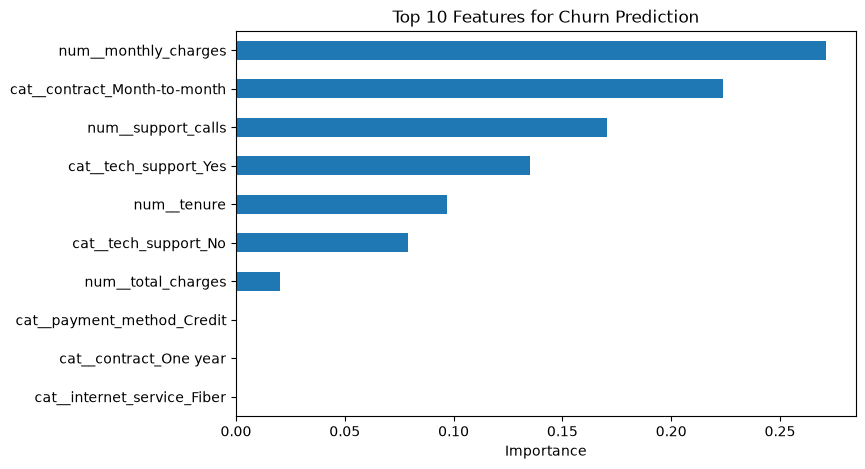

In [77]:
feature_importance.head(10).sort_values().plot(
    kind='barh',
    figsize=(8, 5),
    title='Top 10 Features for Churn Prediction'
)

plt.xlabel('Importance')
plt.show()

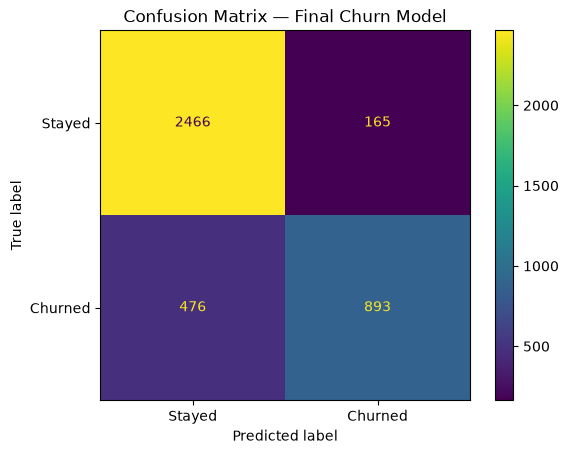

In [78]:
#Confusion Matrix

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_pred,
    display_labels=['Stayed', 'Churned']
)

plt.title('Confusion Matrix — Final Churn Model')
plt.show()

In [80]:
import os

print(os.getcwd())

c:\Python\project


In [82]:
import os

os.makedirs('models', exist_ok=True)

print(os.path.abspath('models'))

c:\Python\project\models


In [83]:
import joblib

joblib.dump(best_model, 'models/churn_model.pkl')

print("Model saved successfully!")

Model saved successfully!


In [84]:
import os

print(os.path.exists('models/churn_model.pkl'))

True


the Churn Prediction Function

In [85]:
def predict_churn(tenure, monthly_charges, total_charges, contract,
                  payment_method, internet_service, tech_support,
                  online_security, support_calls):

    customer = pd.DataFrame([{
        'tenure': tenure,
        'monthly_charges': monthly_charges,
        'total_charges': total_charges,
        'contract': contract,
        'payment_method': payment_method,
        'internet_service': internet_service,
        'tech_support': tech_support,
        'online_security': online_security,
        'support_calls': support_calls
    }])

    probability = best_model.predict_proba(customer)[0, 1]
    prediction = int(probability >= 0.5)

    if probability >= 0.70:
        risk = 'High Risk'
    elif probability >= 0.40:
        risk = 'Medium Risk'
    else:
        risk = 'Low Risk'

    return probability, prediction, risk

In [86]:
probability, prediction, risk = predict_churn(
    tenure=6,
    monthly_charges=90,
    total_charges=540,
    contract='Month-to-month',
    payment_method='UPI',
    internet_service='Fiber',
    tech_support='No',
    online_security='No',
    support_calls=5
)

print(f"Churn Probability: {probability:.2%}")
print(f"Prediction: {'Churn' if prediction == 1 else 'Stay'}")
print(f"Risk Level: {risk}")

Churn Probability: 95.26%
Prediction: Churn
Risk Level: High Risk


Easy Customer Prediction Interface

In [ ]:
'''tenure = int(input("Tenure (months): "))
monthly_charges = float(input("Monthly charges: "))
total_charges = float(input("Total charges: "))
contract = input("Contract (Month-to-month / One year / Two year): ")
payment_method = input("Payment method (Credit / Debit / Cash / UPI): ")
internet_service = input("Internet service (Fiber / DSL / Unknown): ")
tech_support = input("Tech support (Yes / No): ")
online_security = input("Online security (Yes / No): ")
support_calls = int(input("Support calls: "))

probability, prediction, risk = predict_churn(
    tenure,
    monthly_charges,
    total_charges,
    contract,
    payment_method,
    internet_service,
    tech_support,
    online_security,
    support_calls
)

print("\n--- Customer Churn Prediction ---")
print(f"Churn Probability: {probability:.2%}")
print(f"Prediction: {'Churn' if prediction == 1 else 'Stay'}")
print(f"Risk Level: {risk}")    
'''

In [88]:
#Final Model Comparison Table

results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'Gradient Boosting'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, gb_pred)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, logistic_model.predict_proba(X_test)[:, 1]),
        roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1]),
        roc_auc_score(y_test, gb_model.predict_proba(X_test)[:, 1])
    ]
})

results.round(3)

,Model,Accuracy,ROC-AUC
0,Logistic Regression,0.776,0.775
1,Random Forest,0.835,0.795
2,Gradient Boosting,0.838,0.811


In [89]:
print(classification_report(y_test, best_pred))

              precision    recall  f1-score   support

           0       0.84      0.94      0.88      2631
           1       0.84      0.65      0.74      1369

    accuracy                           0.84      4000
   macro avg       0.84      0.79      0.81      4000
weighted avg       0.84      0.84      0.83      4000



In [90]:
#Final Business Insights

features = ['contract', 'payment_method', 'internet_service',
            'tech_support', 'online_security']

for feature in features:
    print(f"\n{feature.upper()}")
    print(
        pd.crosstab(
            df[feature],
            df['churn'],
            normalize='index'
        )['Yes'].mul(100).round(2)
    )


CONTRACT
contract
Month-to-month    43.18
One year          20.92
Two year          20.93
Name: Yes, dtype: float64

PAYMENT_METHOD
payment_method
Cash      34.05
Credit    34.18
Debit     34.11
UPI       34.52
Name: Yes, dtype: float64

INTERNET_SERVICE
internet_service
DSL        33.86
Fiber      34.29
Unknown    35.22
Name: Yes, dtype: float64

TECH_SUPPORT
tech_support
No     41.39
Yes    20.79
Name: Yes, dtype: float64

ONLINE_SECURITY
online_security
No     33.97
Yes    34.58
Name: Yes, dtype: float64


In [91]:
pd.crosstab(
    df['tech_support'],
    df['churn'],
    normalize='index'
)['Yes'].mul(100).round(2)

tech_support
No     41.39
Yes    20.79
Name: Yes, dtype: float64

In [92]:
print("FINAL MODEL: Gradient Boosting")
print("Accuracy:", round(accuracy_score(y_test, best_pred), 3))
print("ROC-AUC:", round(
    roc_auc_score(y_test, best_model.predict_proba(X_test)[:, 1]), 3
))
print("Churn Recall:", round(
    classification_report(y_test, best_pred, output_dict=True)['1']['recall'], 3
))
print("Churn F1:", round(
    classification_report(y_test, best_pred, output_dict=True)['1']['f1-score'], 3
))

print("\nBest Parameters:")
print(grid_search.best_params_)

FINAL MODEL: Gradient Boosting
Accuracy: 0.84
ROC-AUC: 0.811
Churn Recall: 0.652
Churn F1: 0.736

Best Parameters:
{'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 200}
